<a href="https://colab.research.google.com/github/rodrigologin0-cpu/Rodrigo-de-Souza-Lima/blob/main/Narx_Step_ahead.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# NARX POLINOMIAL GENÉRICO COM PREVISÃO N PASSOS À FRENTE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# ============================================================
# 1. Upload
# ============================================================

print("Faça upload do arquivo Excel (.xlsx)")
uploaded = files.upload()

arquivo = list(uploaded.keys())[0]
df = pd.read_excel(arquivo)

print("\nColunas encontradas:")
for col in df.columns:
    print("-", col)

Faça upload do arquivo Excel (.xlsx)


Saving zona_01.xlsx to zona_01.xlsx

Colunas encontradas:
- TARGET
- VAZÃO GÁS 
- POTÊNCIA
- VÁLVULA 
- TEMP_Z3
- TEMP_Z5


In [4]:
# ============================================================
# 2. Configurações
# ============================================================

col_y = input("\nDigite o nome da variável de saída Y: ")

n_inputs = int(input("Quantas entradas exógenas o modelo terá? "))

cols_u = []
for i in range(n_inputs):
    col = input(f"Digite o nome da entrada U{i+1}: ")
    cols_u.append(col)

n_lags_y = int(input("Quantos atrasos da saída Y usar? Exemplo: 2: "))
n_lags_u = int(input("Quantos atrasos das entradas U usar? Exemplo: 2: "))

horizonte = int(input("Quantos passos à frente deseja prever? Exemplo: 1, 5, 10: "))

grau_polinomio = int(input("Ordem do polinômio. Exemplo: 1, 2 ou 3: "))

usar_ridge = input("Usar regularização Ridge? (s/n): ").lower() == "s"



Digite o nome da variável de saída Y: TARGET
Quantas entradas exógenas o modelo terá? 4
Digite o nome da entrada U1: VAZÃO GÁS 
Digite o nome da entrada U2: POTÊNCIA
Digite o nome da entrada U3: TEMP_Z3
Digite o nome da entrada U4: TEMP_Z5
Quantos atrasos da saída Y usar? Exemplo: 2: 2
Quantos atrasos das entradas U usar? Exemplo: 2: 2
Quantos passos à frente deseja prever? Exemplo: 1, 5, 10: 10
Ordem do polinômio. Exemplo: 1, 2 ou 3: 2
Usar regularização Ridge? (s/n): s


In [5]:
# ============================================================
# 3. Montagem dos atrasos
# ============================================================

data = df.copy()

for lag in range(1, n_lags_y + 1):
    data[f"{col_y}_t-{lag}"] = data[col_y].shift(lag)

for col in cols_u:
    for lag in range(1, n_lags_u + 1):
        data[f"{col}_t-{lag}"] = data[col].shift(lag)

# alvo deslocado para previsão N passos à frente
data[f"{col_y}_target_t+{horizonte}"] = data[col_y].shift(-horizonte)

data = data.dropna().reset_index(drop=True)

feature_cols = [c for c in data.columns if "_t-" in c]

X_base = data[feature_cols]
y = data[f"{col_y}_target_t+{horizonte}"]

print("\nVariáveis usadas como entrada:")
for c in feature_cols:
    print("-", c)

print(f"\nAlvo do modelo: {col_y}(t+{horizonte})")


Variáveis usadas como entrada:
- TARGET_t-1
- TARGET_t-2
- VAZÃO GÁS _t-1
- VAZÃO GÁS _t-2
- POTÊNCIA_t-1
- POTÊNCIA_t-2
- TEMP_Z3_t-1
- TEMP_Z3_t-2
- TEMP_Z5_t-1
- TEMP_Z5_t-2

Alvo do modelo: TARGET(t+10)


In [6]:
# ============================================================
# 4. Separação treino/teste temporal
# ============================================================

train_size = int(len(data) * 0.8)

X_train_base = X_base.iloc[:train_size]
X_test_base  = X_base.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

# eixo temporal do teste
idx_test = np.arange(train_size, len(data))

In [7]:
# ============================================================
# 5. Normalização
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_base)
X_test_scaled  = scaler.transform(X_test_base)


In [8]:
# ============================================================
# 6. Expansão polinomial
# ============================================================

poly = PolynomialFeatures(
    degree=grau_polinomio,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly  = poly.transform(X_test_scaled)

nomes_features = poly.get_feature_names_out(feature_cols)

print(f"\nNúmero de termos polinomiais: {len(nomes_features)}")


Número de termos polinomiais: 65


In [9]:
# ============================================================
# 7. Treinamento
# ============================================================

if usar_ridge:
    alpha = float(input("Digite o alpha da Ridge. Exemplo: 0.1, 1, 10: "))
    modelo = Ridge(alpha=alpha)
else:
    modelo = LinearRegression()

modelo.fit(X_train_poly, y_train)

Digite o alpha da Ridge. Exemplo: 0.1, 1, 10: 10


Ridge(alpha=10.0)

In [10]:
# ============================================================
# 8. Predição
# ============================================================

y_pred_train = modelo.predict(X_train_poly)
y_pred_test  = modelo.predict(X_test_poly)


In [11]:
# ============================================================
# 9. Métricas
# ============================================================

def metricas(y_real, y_pred, nome):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)

    print(f"\nMétricas - {nome}")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"R²   = {r2:.4f}")

metricas(y_train, y_pred_train, "Treino")
metricas(y_test, y_pred_test, f"Teste - previsão {horizonte} passos à frente")



Métricas - Treino
MAE  = 0.8219
RMSE = 1.0731
R²   = 0.9988

Métricas - Teste - previsão 10 passos à frente
MAE  = 1.5730
RMSE = 2.1568
R²   = 0.9973



Quantas amostras deseja mostrar no gráfico? Exemplo: 300: 10000


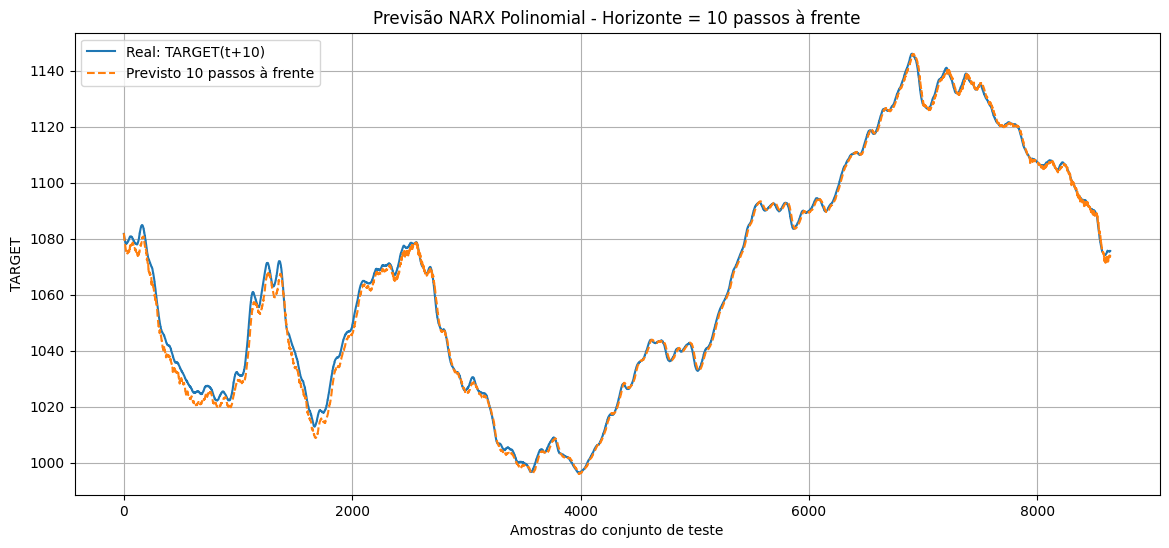

In [20]:
# ============================================================
# 10. Gráfico enfatizando previsão passo à frente
# ============================================================

n_plot = int(input("\nQuantas amostras deseja mostrar no gráfico? Exemplo: 300: "))

y_test_plot = y_test.values[:n_plot]
y_pred_plot = y_pred_test[:n_plot]

plt.figure(figsize=(14,6))
plt.plot(y_test_plot, label=f"Real: {col_y}(t+{horizonte})")
plt.plot(y_pred_plot, linestyle="--", label=f"Previsto {horizonte} passos à frente")

plt.title(f"Previsão NARX Polinomial - Horizonte = {horizonte} passos à frente")
plt.xlabel("Amostras do conjunto de teste")
plt.ylabel(col_y)
plt.legend()
plt.grid(True)
plt.show()

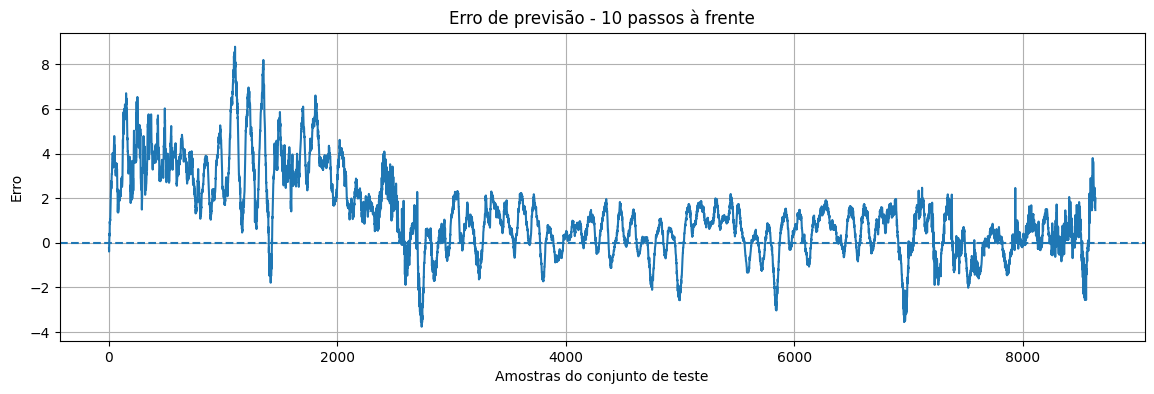

In [21]:

# ============================================================
# 11. Gráfico de erro
# ============================================================

erro = y_test.values - y_pred_test

plt.figure(figsize=(14,4))
plt.plot(erro[:n_plot])
plt.axhline(0, linestyle="--")
plt.title(f"Erro de previsão - {horizonte} passos à frente")
plt.xlabel("Amostras do conjunto de teste")
plt.ylabel("Erro")
plt.grid(True)
plt.show()


In [17]:
# ============================================================
# 12. Coeficientes
# ============================================================

coeficientes = pd.DataFrame({
    "Termo": nomes_features,
    "Coeficiente": modelo.coef_
})

coeficientes["Abs"] = coeficientes["Coeficiente"].abs()
coeficientes = coeficientes.sort_values("Abs", ascending=False)

print("\nBias / Intercepto:")
print(modelo.intercept_)

print("\nPrincipais coeficientes:")
display(coeficientes.head(20))

coef_export = pd.DataFrame({
    "Termo": nomes_features,
    "Coeficiente": modelo.coef_
})

coef_export.loc[len(coef_export)] = ["Bias", modelo.intercept_]
coef_export.to_excel("coeficientes_narx_polinomial_horizonte.xlsx", index=False)

files.download("coeficientes_narx_polinomial_horizonte.xlsx")

print("\nArquivo gerado: coeficientes_narx_polinomial_horizonte.xlsx")


Bias / Intercepto:
1052.5869915764663

Principais coeficientes:


,Termo,Coeficiente,Abs
0,TARGET_t-1,20.944935,20.944935
1,TARGET_t-2,9.822875,9.822875
7,TEMP_Z3_t-2,-2.359171,2.359171
6,TEMP_Z3_t-1,1.917155,1.917155
61,TEMP_Z3_t-2 TEMP_Z5_t-2,-0.937330,0.937330
57,TEMP_Z3_t-1 TEMP_Z5_t-1,0.868797,0.868797
60,TEMP_Z3_t-2 TEMP_Z5_t-1,-0.822992,0.822992
26,TARGET_t-2 TEMP_Z3_t-2,-0.780350,0.780350
16,TARGET_t-1 TEMP_Z3_t-1,0.771508,0.771508
58,TEMP_Z3_t-1 TEMP_Z5_t-2,0.746871,0.746871


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Arquivo gerado: coeficientes_narx_polinomial_horizonte.xlsx
